# Data Cleansing

### Insights 
Problem Statement: How can organizations optimize their global talent acquisition and compensation strategies by analyzing the key drivers of salary variation in Data Science, Machine Learning, and AI roles in 2025?

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import mean

df = pd.read_csv("salaries.csv")

In [72]:
df.duplicated().sum()  # Number of duplicate rows
df = df.drop_duplicates()

In [73]:
# Convert coded values to readable labels (optional)
exp_map = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
df['experience_level'] = df['experience_level'].map(exp_map)

size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
df['company_size'] = df['company_size'].map(size_map)

### Salary by experience level

In [74]:
df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=False)

experience_level
Executive      201167.041418
Senior         167831.982119
Mid-level      136625.381119
Entry-level     97892.494908
Name: salary_in_usd, dtype: float64

### Remote vs Onsite Salary

In [75]:
df['remote_status'] = df['remote_ratio'].apply(lambda x: 'Remote' if x == 100 else ('Hybrid' if x > 0 else 'On-site'))
df.groupby('remote_status')['salary_in_usd'].mean()

remote_status
Hybrid      81625.033742
On-site    152186.577255
Remote     149213.231412
Name: salary_in_usd, dtype: float64

### Top Paying Job Titles

In [76]:
df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

job_title
Research Team Lead               450000.000000
Analytics Engineering Manager    399880.000000
Data Science Tech Lead           375000.000000
Applied AI ML Lead               292500.000000
IT Enterprise Data Architect     284090.000000
Head of Applied AI               278500.000000
Head of Machine Learning         276100.692308
Director of Data                 270000.000000
Director of Machine Learning     265200.000000
AIRS Solutions Specialist        263250.000000
Name: salary_in_usd, dtype: float64

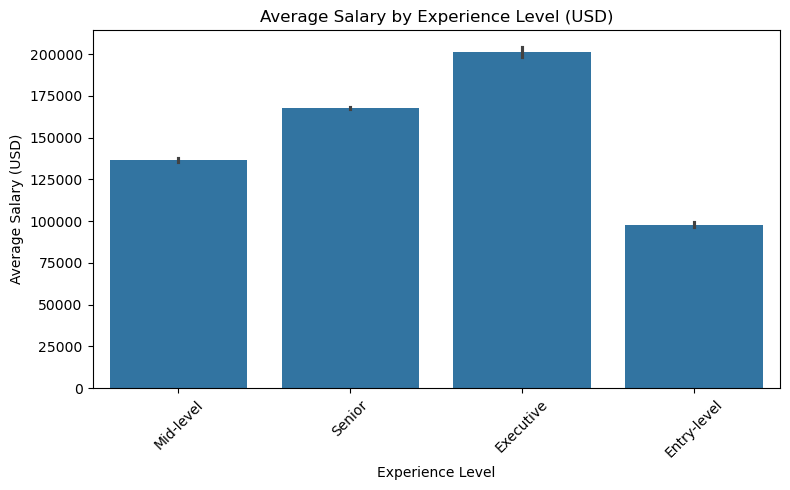

In [77]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='experience_level', y='salary_in_usd', estimator=mean)
plt.title('Average Salary by Experience Level (USD)')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
df['remote_status'] = df['remote_ratio'].apply(
    lambda x: 'Remote' if x == 100 else ('Hybrid' if x > 0 else 'On-site')
)


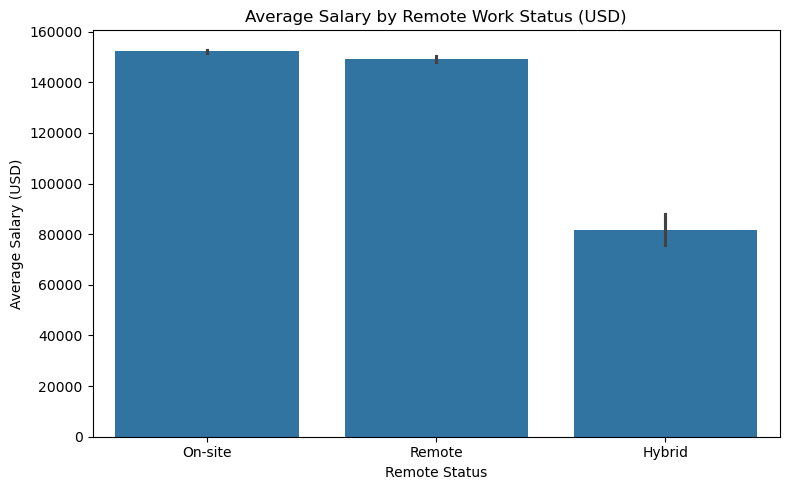

In [79]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='remote_status', y='salary_in_usd', estimator=mean)
plt.title('Average Salary by Remote Work Status (USD)')
plt.xlabel('Remote Status')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()

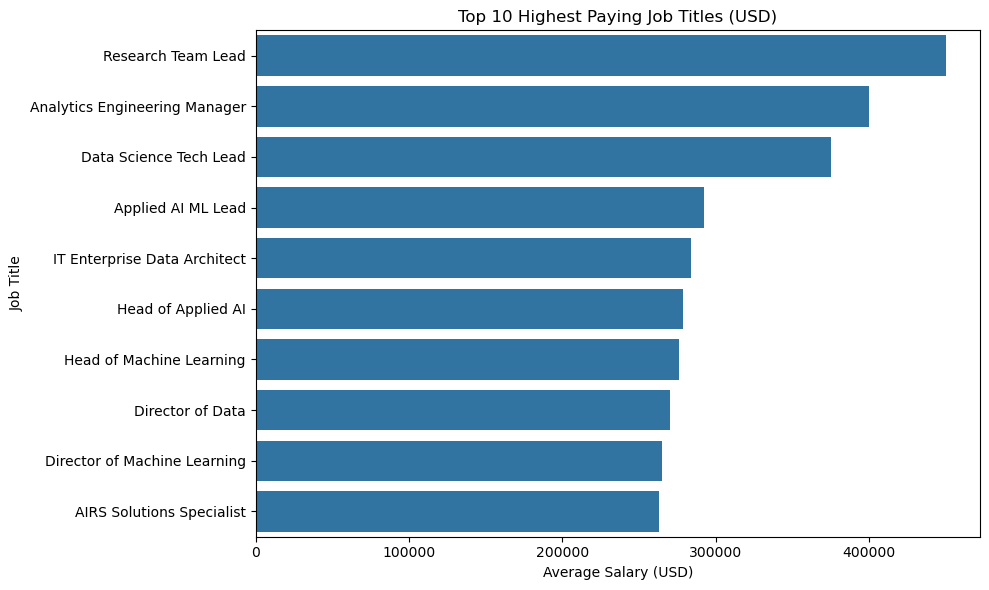

In [80]:
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, orient='h')
plt.title('Top 10 Highest Paying Job Titles (USD)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()


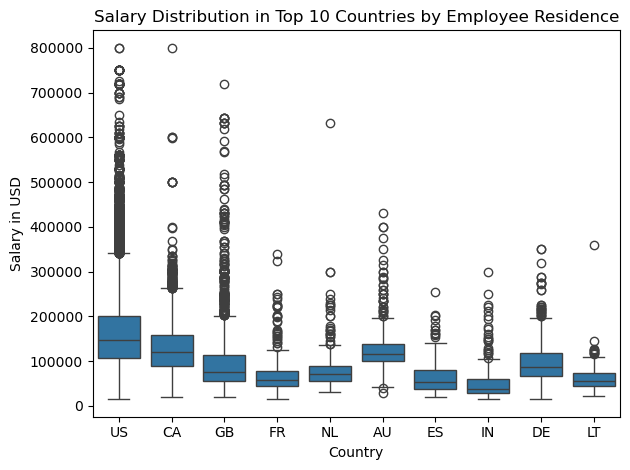

In [81]:
top_countries = df['employee_residence'].value_counts().head(10).index
top_countries_df = df[df['employee_residence'].isin(top_countries)]

sns.boxplot(data=top_countries_df, x='employee_residence', y='salary_in_usd')
plt.title('Salary Distribution in Top 10 Countries by Employee Residence')
plt.xlabel('Country')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

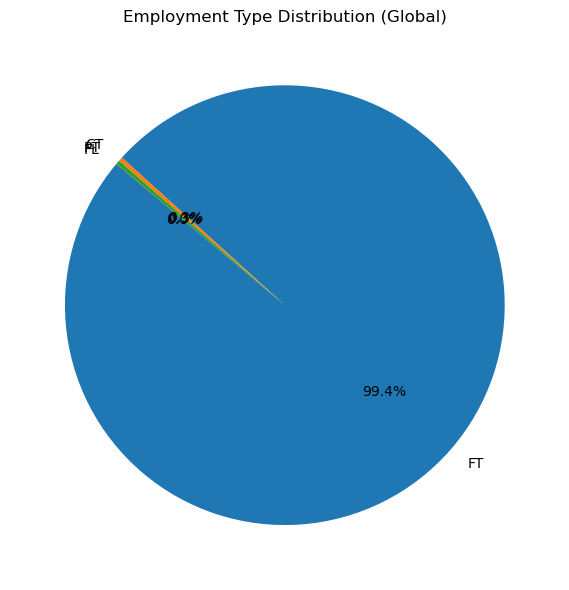

In [91]:
df = pd.read_csv("salaries.csv")

df['experience_level'] = df['experience_level'].map({'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'})
df['company_size'] = df['company_size'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})
df['remote_status'] = df['remote_ratio'].apply(lambda x: 'Remote' if x == 100 else ('Hybrid' if x > 0 else 'On-site'))

employment_dist = df['employment_type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(employment_dist, labels=employment_dist.index, autopct='%1.1f%%', startangle=140)
plt.title('Employment Type Distribution (Global)')
plt.tight_layout()
plt.show()

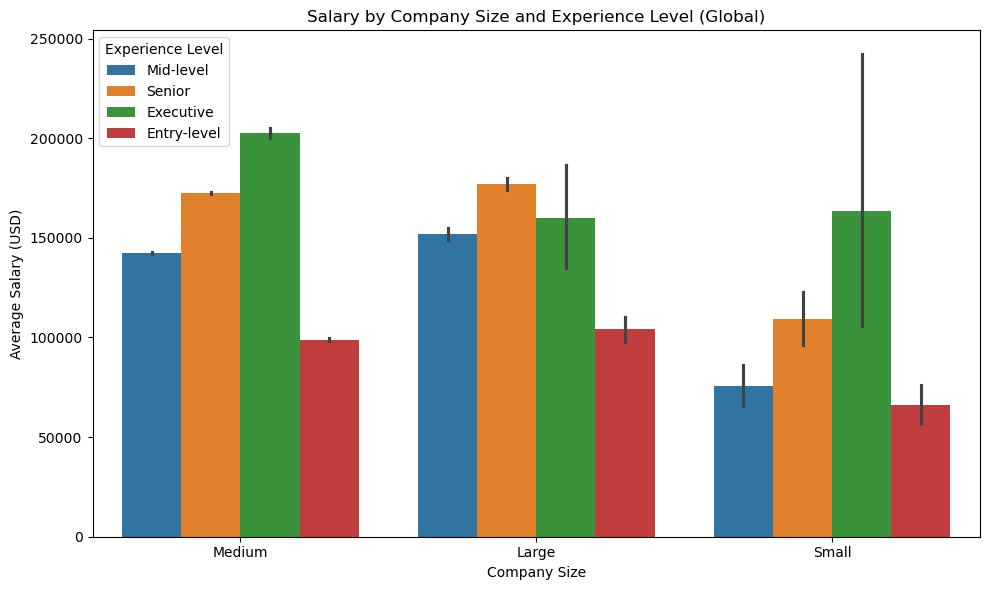

In [92]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='company_size', y='salary_in_usd', hue='experience_level', estimator=np.mean)
plt.title('Salary by Company Size and Experience Level (Global)')
plt.xlabel('Company Size')
plt.ylabel('Average Salary (USD)')
plt.legend(title='Experience Level')
plt.tight_layout()
plt.show()

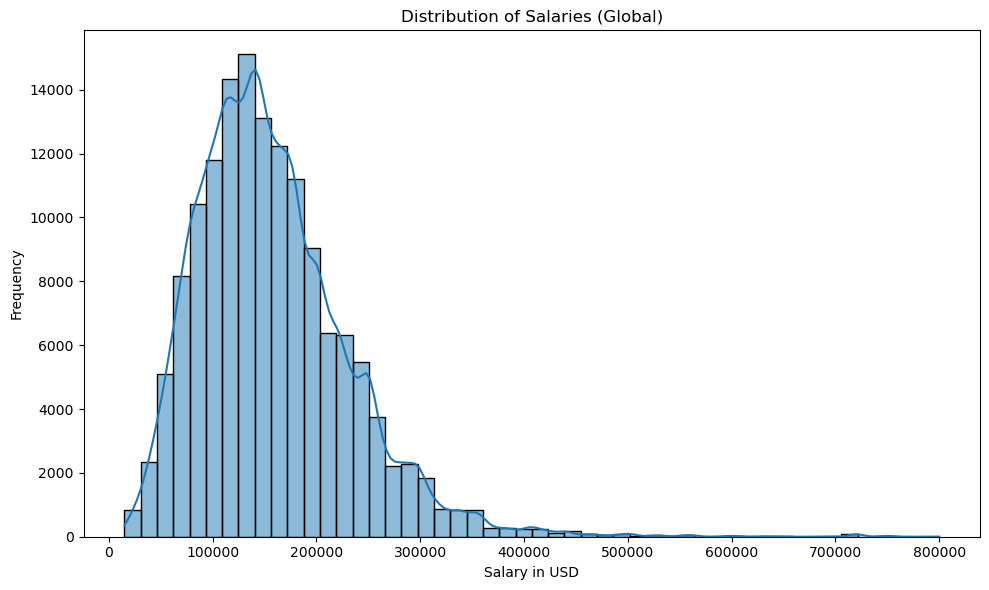

In [93]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=50, kde=True)
plt.title('Distribution of Salaries (Global)')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

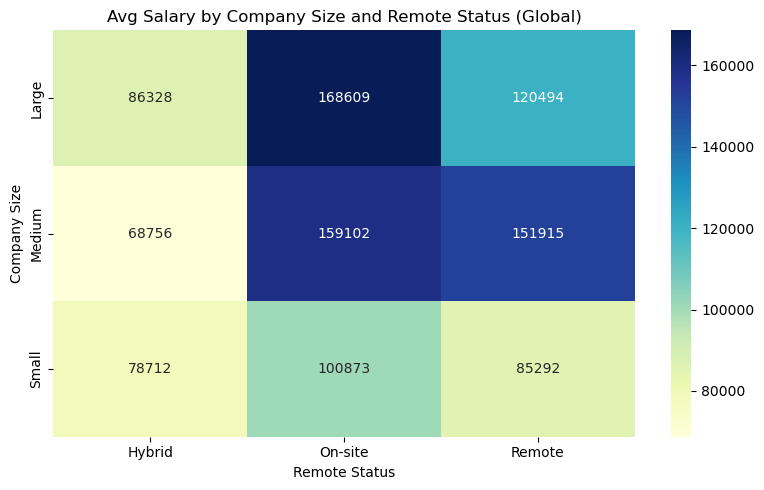

In [58]:
heatmap_data = df.groupby(['company_size', 'remote_status'])['salary_in_usd'].mean().unstack()
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Avg Salary by Company Size and Remote Status (Global)')
plt.xlabel('Remote Status')
plt.ylabel('Company Size')
plt.tight_layout()
plt.show()